# Multinomial Naive Bayes on real review data

This notebook demonstrates Multinomial Naive Bayes on a real labeled music-review dataset. Reviews are labeled positive or negative, and the model uses word counts as features.

The repository stores a deterministic, compact subset of the data so the notebook remains quick to run: 500 reviews per class for training and 200 reviews per class for testing. The test reviews remain separate and are not used to estimate the vocabulary or probabilities.

## Load and tokenize the reviews

Each CSV row contains a review and its label. We lowercase the review and keep alphabetic word tokens. This simple tokenizer is intentionally visible: preprocessing determines what the model can learn from the text.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from algorithms.multinomial_naive_bayes import multinomial_naive_bayes_classifier
from algorithms.preprocessors import doc_to_bow_vector

DATA_DIR = Path("data/naive_bayes")
RESULTS_DIR = Path("results/naive_bayes")
FIGURES_DIR = Path("figures/naive_bayes")

def tokenize(text):
    # A token is a contiguous sequence of letters.
    return re.findall(r"[a-z]+", text.lower())

def load_review_split(split, number_per_class):
    documents = []
    labels = []
    frames = {}
    for label in ("positive", "negative"):
        frame = pd.read_csv(DATA_DIR / f"{split}-{label}.csv").head(number_per_class)
        frames[label] = frame
        documents.extend(frame["reviewText"].map(tokenize))
        labels.extend([label] * len(frame))
    return documents, labels, frames

X_train, y_train, train_frames = load_review_split("train", 500)
X_test, y_test, test_frames = load_review_split("test", 200)

# Build the vocabulary from training reviews only.
vocab = sorted({word for document in X_train for word in document})
print(f"training reviews={len(X_train)}, test reviews={len(X_test)}")
print(f"vocabulary size={len(vocab)}")
print("example review:", train_frames["positive"].iloc[0]["reviewText"][:180], "...")

training reviews=1000, test reviews=400
vocabulary size=11527
example review: I loved the Monkees and think that Michael Nesmith, as a solo artist, is superb!  Besides his wonderful voice he is quirky, clever and so much fun to listen to. ...


## From documents to probabilities

A review is represented as a bag of words: one fixed-length vector of word counts. The vocabulary is a shared coordinate system, so every vector position has the same meaning for every review.

In [2]:
# Show the conversion from one real review to its count representation.
example_document = X_train[0]
example_vector = doc_to_bow_vector(example_document, vocab)
nonzero_counts = {
    word: count
    for word, count in zip(vocab, example_vector)
    if count > 0
}

print("first tokens:", example_document[:20])
print("nonzero word counts:", dict(list(nonzero_counts.items())[:20]))
print("number of vocabulary positions:", len(example_vector))

first tokens: ['i', 'loved', 'the', 'monkees', 'and', 'think', 'that', 'michael', 'nesmith', 'as', 'a', 'solo', 'artist', 'is', 'superb', 'besides', 'his', 'wonderful', 'voice', 'he']
nonzero word counts: {'a': 1, 'and': 2, 'artist': 1, 'as': 1, 'besides': 1, 'clever': 1, 'fun': 1, 'he': 1, 'his': 1, 'i': 1, 'is': 2, 'listen': 1, 'loved': 1, 'michael': 1, 'monkees': 1, 'much': 1, 'nesmith': 1, 'quirky': 1, 'so': 1, 'solo': 1}
number of vocabulary positions: 11527


## Conditional independence

Repeated words produce larger counts, missing words produce count 0, and words outside the training vocabulary are ignored. The vector is the interface between language and the probability calculation.

Probabilistically, events A and B are independent when their joint probability factors as $P(A \cap B) = P(A)P(B)$. Naive Bayes uses conditional independence: after conditioning on class c, it assumes $P(w_1, w_2 \mid c) = P(w_1 \mid c)P(w_2 \mid c)$. This ignores relationships such as word order and phrases so that each word contribution can be estimated separately.

In [3]:
# Fit with additive smoothing and log probabilities.
model = multinomial_naive_bayes_classifier(alpha=1.0, log_scale=True)
model.fit(X_train, y_train, vocab)
predictions = model.predict(X_test)

accuracy = np.mean(np.asarray(predictions) == np.asarray(y_test))
print("predictions:", predictions[:10])
print(f"test accuracy: {accuracy:.3f}")
print("class log-priors:", model.class_prior_probabilities)

# These are log P(word | class), so larger values indicate stronger evidence.
interesting_words = [
    word for word in ("love", "great", "good", "bad", "disappointing", "excellent")
    if word in vocab
]
word_probabilities = pd.DataFrame(
    model.word_probabilities_given_class,
    index=vocab,
)
word_probabilities.loc[interesting_words]

predictions: ['positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'negative']
test accuracy: 0.807
class log-priors: {'positive': -0.6931471805599453, 'negative': -0.6931471805599453}


,positive,negative
love,-6.023318,-6.854733
great,-5.548860,-6.668147
good,-6.091036,-6.117692
bad,-7.889185,-6.529311
disappointing,-10.048670,-8.572385
excellent,-7.563763,-8.572385


## From counts to a class score

For a count vector with count $n_j$ for word $w_j$, the score for class c is proportional to $P(c)\prod_j P(w_j \mid c)^{n_j}$. A word that is common in one class increases that class score, and repeating the word applies its evidence again.

The implementation uses log probabilities. The product becomes the sum $\log P(c) + \sum_j n_j \log P(w_j \mid c)$, which is mathematically equivalent and avoids numerical underflow.

## What does smoothing change?

Additive smoothing, controlled by $\alpha$, adds $\alpha$ pseudo-counts to every vocabulary word. Without smoothing, a word absent from one class would receive probability zero and dominate the product. Smoothing makes that probability small instead of zero.

A small $\alpha$ preserves class-specific differences, while a larger $\alpha$ makes word probabilities more uniform. The next sweep keeps the real dataset and fixed train/test split unchanged while varying only $\alpha$.

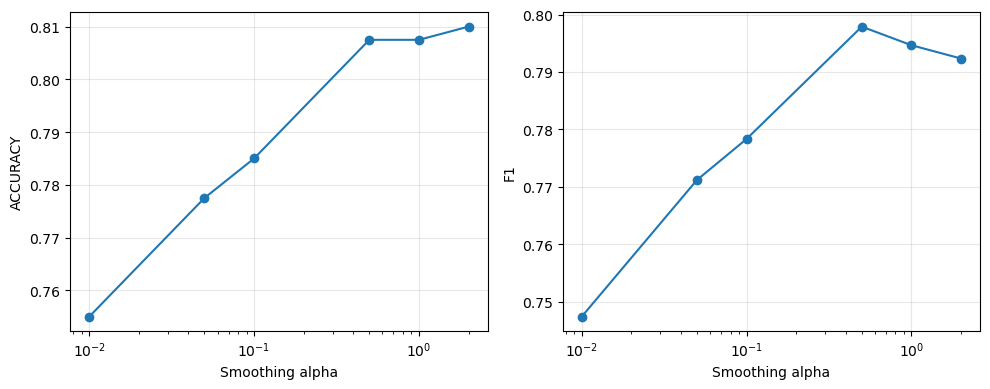

,alpha,accuracy,f1
0,0.01,0.7550,0.747423
1,0.05,0.7775,0.771208
2,0.10,0.7850,0.778351
3,0.50,0.8075,0.797900
4,1.00,0.8075,0.794667
5,2.00,0.8100,0.792350


In [4]:
def f1_score(labels, predictions, positive_label="positive"):
    labels = np.asarray(labels)
    predictions = np.asarray(predictions)
    true_positive = np.sum((labels == positive_label) & (predictions == positive_label))
    false_positive = np.sum((labels != positive_label) & (predictions == positive_label))
    false_negative = np.sum((labels == positive_label) & (predictions != positive_label))
    precision = true_positive / max(true_positive + false_positive, 1)
    recall = true_positive / max(true_positive + false_negative, 1)
    return 2 * precision * recall / max(precision + recall, 1e-12)

alphas = (0.01, 0.05, 0.1, 0.5, 1.0, 2.0)
rows = []
for alpha in alphas:
    classifier = multinomial_naive_bayes_classifier(alpha=alpha, log_scale=True)
    classifier.fit(X_train, y_train, vocab)
    predicted = classifier.predict(X_test)
    rows.append({
        "alpha": alpha,
        "accuracy": np.mean(np.asarray(predicted) == np.asarray(y_test)),
        "f1": f1_score(y_test, predicted),
    })

performance = pd.DataFrame(rows)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
performance.to_csv(RESULTS_DIR / "alpha_sweep.csv", index=False)

figure, axes = plt.subplots(1, 2, figsize=(10, 4))
for axis, metric in zip(axes, ("accuracy", "f1")):
    axis.plot(performance["alpha"], performance[metric], marker="o")
    axis.set_xscale("log")
    axis.set_xlabel("Smoothing alpha")
    axis.set_ylabel(metric.upper())
    axis.grid(True, alpha=0.3)
figure.tight_layout()
figure.savefig(FIGURES_DIR / "alpha_sweep.png", bbox_inches="tight")
plt.show()
performance

## Interpretation

Naive Bayes is fast because training reduces each class to a prior and a table of word probabilities. Its simplicity is also its main limitation: real words are not conditionally independent, and word order is discarded by the bag-of-words representation.

Because this is a real review dataset, the results reflect a meaningful sentiment-classification task rather than a perfectly separable toy example. When reading the table and plot, ask which words provide class evidence and whether changing $\alpha$ changes the decision. This makes the model's inductive bias visible: frequent class-specific words matter, while smoothing controls how strongly the model trusts individual word counts.